# Task 4 (extension) — Primary Type Multiclass Classification
***

This extends Task 4 beyond a binary Arrest target: Random Forest is
applied to Primary Type instead, a genuinely harder multiclass problem
with far more severe class imbalance. Split
into its own notebook purely so it has a predictable, bounded runtime —
multiclass Gini/entropy impurity calculations scale with the number of
classes (9 here vs. 2 for the binary Arrest target in
`04_classification.ipynb`), which is a genuinely more expensive
computation per tree, not just a larger hyperparameter search.

THEFT alone outnumbers the rarest kept category by roughly 4-5×, and
outnumbers crime types excluded into "OTHER" by far more — a much more
severe skew than the binary Arrest target's ~27/73 split.

In [1]:
import time, json
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
import matplotlib.pyplot as plt
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.ml import Pipeline

import os
from pathlib import Path

# --- Paths ---------------------------------------------------------------
# Resolved relative to the project root (walks up from the notebook's cwd
# until it finds a Data/ folder; override with CHICAGO_PROJECT_ROOT if you
# launch the kernel from elsewhere, e.g. Colab/Databricks).

def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "Data").is_dir():
            return candidate
    return start

PROJECT_ROOT = Path(
    os.environ.get("CHICAGO_PROJECT_ROOT") or _find_project_root(Path.cwd())
).resolve()

PROCESSED = str(PROJECT_ROOT / "data" / "processed")
REPORT_DIR = str(PROJECT_ROOT / "reports")
SPARK_TMP_DIR = str(PROJECT_ROOT / "spark_tmp")

for _d in (REPORT_DIR, SPARK_TMP_DIR):
    os.makedirs(_d, exist_ok=True)

spark = (
    SparkSession.builder.appName("ChicagoCrime-Task4b-Multiclass")
    # Pin the driver to loopback so Spark's internal Netty RPC server
    # doesn't depend on the machine's hostname resolving (macOS .local
    # mDNS names can stop resolving after a network change/sleep-wake,
    # which otherwise crashes SparkContext init with
    # UnresolvedAddressException before any code even runs).
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    # local[*] runs one executor thread per core (12 here) INSIDE the driver's own
    # JVM, so spark.driver.memory is the only heap available for all of them
    # combined. 2g caused repeated OutOfMemoryError crashes once this notebook
    # started .cache()-ing one-hot-encoded multiclass DataFrames on ~7.7M rows
    # (same failure mode fixed in 04_classification.ipynb). 8g is a safe fraction
    # of this machine's 24GB RAM; lower it on a smaller machine.
    .master("local[*]").config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.local.dir", SPARK_TMP_DIR)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

crime = spark.read.parquet(PROCESSED + "/crime_clean_flat")
census = spark.read.parquet(PROCESSED + "/census_community_areas")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/27 16:52:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/27 16:52:52 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


## 1. Same feature engineering as the binary notebook (minus `primary_type`, which is now the label)

In [2]:
top_locations = [r[0] for r in crime.groupBy("location_description")
                  .count().orderBy(F.desc("count")).limit(20).select("location_description").collect()]
enriched = crime.join(F.broadcast(census), on="community_area", how="left")
TWO_PI = 2 * np.pi
feat = (
    enriched
    .withColumn("loc_bucketed", F.when(F.col("location_description").isin(top_locations),
                                        F.col("location_description")).otherwise(F.lit("OTHER_LOC")))
    .withColumn("hour_sin", F.sin(F.col("crime_hour") / 24.0 * TWO_PI))
    .withColumn("hour_cos", F.cos(F.col("crime_hour") / 24.0 * TWO_PI))
    .withColumn("dow_sin", F.sin(F.col("crime_dow") / 7.0 * TWO_PI))
    .withColumn("dow_cos", F.cos(F.col("crime_dow") / 7.0 * TWO_PI))
    .withColumn("month_sin", F.sin(F.col("crime_month") / 12.0 * TWO_PI))
    .withColumn("month_cos", F.cos(F.col("crime_month") / 12.0 * TWO_PI))
    .withColumn("is_weekend_num", F.col("is_weekend").cast("double"))
    .withColumn("domestic_num", F.col("domestic").cast("double"))
    .fillna({"hardship_index": 0.0, "pct_below_poverty": 0.0, "pct_unemployed": 0.0,
             "pct_no_diploma": 0.0, "per_capita_income": 0.0})
    .filter(F.col("crime_year").between(2001, 2022))
)
NUMERIC_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
                     "is_weekend_num", "domestic_num", "hardship_index", "pct_below_poverty",
                     "pct_unemployed", "pct_no_diploma", "per_capita_income"]

top8 = [r[0] for r in crime.groupBy("primary_type").count().orderBy(F.desc("count")).limit(8).collect()]
print("Top 8 classes kept, rest -> OTHER:", top8)

mc_feat = feat.withColumn("primary_type_bucketed",
                           F.when(F.col("primary_type").isin(top8), F.col("primary_type")).otherwise(F.lit("OTHER")))
mc_train_raw = mc_feat.filter(F.col("crime_year") <= 2020)
mc_test_raw = mc_feat.filter(F.col("crime_year") >= 2021)

Top 8 classes kept, rest -> OTHER: ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'NARCOTICS', 'ASSAULT', 'OTHER OFFENSE', 'BURGLARY', 'MOTOR VEHICLE THEFT']


## 2. Same time-based split as the binary notebook (2001-2020 train / 2021-2022 test)

In [3]:
mc_label_idx = StringIndexer(inputCol="primary_type_bucketed", outputCol="mc_label", handleInvalid="keep")
mc_indexers = [
    StringIndexer(inputCol="loc_bucketed", outputCol="loc_idx", handleInvalid="keep"),
    StringIndexer(inputCol="district", outputCol="district_idx", handleInvalid="keep"),
]
mc_encoder = OneHotEncoder(inputCols=["loc_idx", "district_idx"], outputCols=["loc_ohe", "district_ohe"])
mc_assembler = VectorAssembler(inputCols=["loc_ohe", "district_ohe"] + NUMERIC_FEATURES,
                                outputCol="features", handleInvalid="skip")

mc_pipeline = Pipeline(stages=[mc_label_idx] + mc_indexers + [mc_encoder]).fit(mc_train_raw)
mc_train = mc_assembler.transform(mc_pipeline.transform(mc_train_raw)).select("features", "mc_label").cache()
mc_test = mc_assembler.transform(mc_pipeline.transform(mc_test_raw)).select("features", "mc_label").cache()
n_mc_train, n_mc_test = mc_train.count(), mc_test.count()
print(f"Multiclass train={n_mc_train:,} test={n_mc_test:,}")

Multiclass train=7,264,738 test=446,786


## 3. Train unweighted and class-weighted multiclass Random Forests

Spark `GBTClassifier` supports binary classification only, so Random Forest is used for this multiclass extension. To move beyond merely observing imbalance, a second model uses inverse-frequency class weights calculated from the training partition only. This allows direct comparison of whether weighting improves minority-class recall and macro-level performance.


In [4]:
# Training-set class support and inverse-frequency weights.
train_label_counts = mc_train.groupBy("mc_label").count().cache()
n_classes = train_label_counts.count()
class_weight_map = {float(r["mc_label"]): float(n_mc_train / (n_classes * r["count"])) for r in train_label_counts.collect()}
weight_expr = F.create_map(*[x for kv in class_weight_map.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])
mc_train_weighted = mc_train.withColumn("class_weight", F.element_at(weight_expr, F.col("mc_label")))

models = {
    "RF_unweighted": RandomForestClassifier(featuresCol="features", labelCol="mc_label", numTrees=25, maxDepth=8, seed=42),
    "RF_weighted": RandomForestClassifier(featuresCol="features", labelCol="mc_label", weightCol="class_weight", numTrees=25, maxDepth=8, seed=42),
}
mc_models = {}
for name, estimator in models.items():
    t0 = time.time()
    train_input = mc_train_weighted if name == "RF_weighted" else mc_train
    mc_models[name] = estimator.fit(train_input)
    print(f"Trained {name} in {time.time()-t0:.1f}s")


Trained RF_unweighted in 86.0s


Trained RF_weighted in 91.2s


## 4. Per-class evaluation — quantify how skew affects precision and recall

Evaluation reports per-class precision, recall and F1 for each model, together with actual training support. Macro-F1 is calculated explicitly so large classes cannot dominate the headline metric, while weighted F1 shows performance under the observed class distribution.


/Users/damithkayatech.com/Documents/MSc/BD Technologies Assignment/PRAC 1/Chicago_Crime_Analysis_Project/.venv/lib/python3.11/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


        model  label          class_name  train_support  precision   recall       f1
RF_unweighted    0.0               THEFT        1531352   0.290924 0.825284 0.430198
RF_unweighted    1.0             BATTERY        1329506   0.405699 0.602277 0.484819
RF_unweighted    2.0               OTHER        1188192   0.322009 0.066929 0.110823
RF_unweighted    3.0     CRIMINAL DAMAGE         826577   0.273381 0.001452 0.002890
RF_unweighted    4.0           NARCOTICS         736089   0.125556 0.419588 0.193277
RF_unweighted    5.0             ASSAULT         459967   0.000000 0.000000 0.000000
RF_unweighted    6.0       OTHER OFFENSE         450529   0.393939 0.000457 0.000913
RF_unweighted    7.0            BURGLARY         407994   0.130675 0.021613 0.037091
RF_unweighted    8.0 MOTOR VEHICLE THEFT         334532   0.000000 0.000000 0.000000
  RF_weighted    0.0               THEFT        1531352   0.413974 0.374019 0.392983
  RF_weighted    1.0             BATTERY        1329506   0.52436

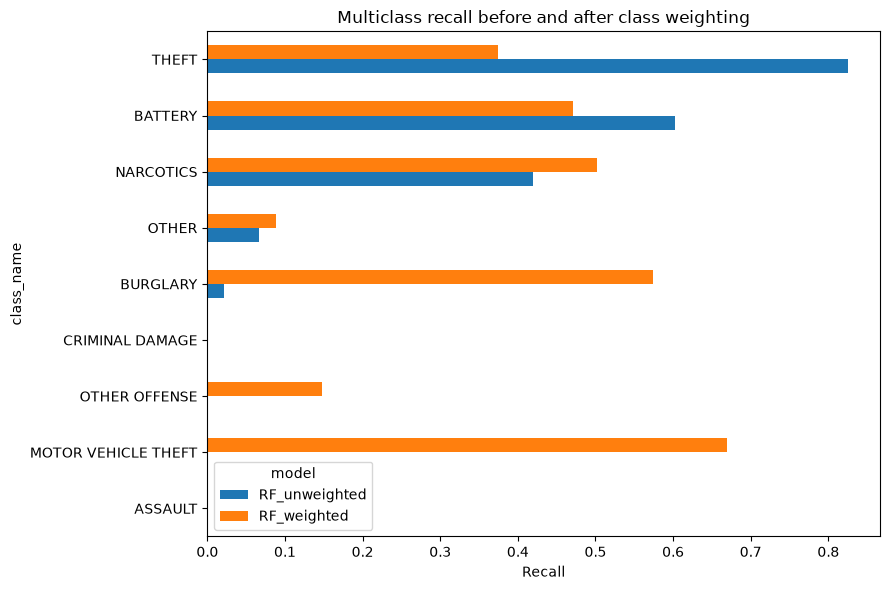

In [5]:
mc_label_fitted = mc_pipeline.stages[0]
name_map = {float(i): lab for i, lab in enumerate(mc_label_fitted.labels)}
train_support = {float(r["mc_label"]): int(r["count"]) for r in train_label_counts.collect()}

all_per_class = []
model_summaries = []
for model_name, model in mc_models.items():
    preds = model.transform(mc_test)
    metrics = MulticlassMetrics(preds.select("prediction", "mc_label").rdd.map(lambda r: (float(r[0]), float(r[1]))))
    labels_sorted = sorted(train_support)
    class_f1s = []
    class_precisions = []
    class_recalls = []
    for lab in labels_sorted:
        p = float(metrics.precision(lab)); r = float(metrics.recall(lab)); f1 = float(metrics.fMeasure(lab))
        class_precisions.append(p); class_recalls.append(r); class_f1s.append(f1)
        all_per_class.append({
            "model": model_name, "label": lab, "class_name": name_map.get(lab, "?"),
            "train_support": train_support[lab], "precision": p, "recall": r, "f1": f1
        })
    model_summaries.append({
        "model": model_name,
        "accuracy": float(metrics.accuracy),
        "weighted_precision": float(metrics.weightedPrecision),
        "weighted_recall": float(metrics.weightedRecall),
        "weighted_f1": float(metrics.weightedFMeasure()),
        "macro_precision": float(np.mean(class_precisions)),
        "macro_recall": float(np.mean(class_recalls)),
        "macro_f1": float(np.mean(class_f1s)),
    })

per_class_df = pd.DataFrame(all_per_class).sort_values(["model", "train_support"], ascending=[True, False])
summary_df = pd.DataFrame(model_summaries)
print(per_class_df.to_string(index=False))
print("Model-level summary:\n", summary_df.to_string(index=False))

# Visualise minority-class recall before/after weighting.
recall_plot = per_class_df.pivot(index="class_name", columns="model", values="recall").sort_values("RF_unweighted")
recall_plot.plot(kind="barh", figsize=(9, 6))
plt.xlabel("Recall")
plt.title("Multiclass recall before and after class weighting")
plt.tight_layout()
plt.show()


## 5. Interpretation of multiclass skew

The central question is whether frequent classes dominate the forest strongly enough to suppress minority-class recall. The table above uses **training supports calculated from the actual 2001–2020 partition**, eliminating the earlier ambiguity created by full-dataset support counts. The unweighted and weighted models can now be compared class by class.

If weighting raises recall for low-support classes while lowering precision for dominant classes, that is direct evidence of the precision–recall cost of correcting skew. Macro-F1 should be emphasised alongside weighted-F1: weighted-F1 can remain deceptively acceptable when large classes perform well, whereas macro-F1 gives each crime category equal influence.

This extension is deliberately treated as an imbalance experiment rather than a claim that primary crime type can be reliably inferred from these administrative predictors. Very low per-class recall is itself a substantive result showing the limits of the feature set.


In [6]:
per_class_df.to_csv(os.path.join(REPORT_DIR, "task4_multiclass_per_class.csv"), index=False)
summary_df.to_csv(os.path.join(REPORT_DIR, "task4_multiclass_model_summary.csv"), index=False)
with open(os.path.join(REPORT_DIR, "task4_multiclass_summary.json"), "w") as f:
    json.dump({
        "n_train": int(n_mc_train), "n_test": int(n_mc_test),
        "train_support_by_label": {str(k): int(v) for k, v in train_support.items()},
        "class_weight_by_label": {str(k): float(v) for k, v in class_weight_map.items()},
        "model_summaries": model_summaries,
    }, f, indent=2)

print("Task 4 (multiclass extension) complete.")
spark.stop()


Task 4 (multiclass extension) complete.
